## 1.1 Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.2 Importing Dataset

In [2]:
train_data = pd.read_excel("Data_Train.xlsx")

In [3]:
train_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
train_data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
20677,Jet Airways,9/05/2019,Kolkata,Banglore,CCU → BOM → BLR,18:39,03:59 10 May,9h 20m,1 stop,In-flight meal not included,13514
20678,Multiple carriers,21/03/2019,Delhi,Cochin,DEL → BOM → COK,16:29,11:49 22 Mar,19h 20m,1 stop,No info,18255
20679,Air Asia,15/04/2019,Kolkata,Banglore,CCU → BLR,05:36,09:06,3h 30m,non-stop,No info,2314
20680,Air India,21/05/2019,Kolkata,Banglore,CCU → BBI → BOM → BLR,00:50,22:05,21h 15m,2 stops,No info,12334
20681,Jet Airways,3/06/2019,Delhi,Cochin,DEL → BOM → COK,08:59,23:44,14h 45m,1 stop,In-flight meal not included,17104


## 2.1 Let's deal with missing values

In [5]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20682 entries, 0 to 20681
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          20682 non-null  str  
 1   Date_of_Journey  20682 non-null  str  
 2   Source           20682 non-null  str  
 3   Destination      20682 non-null  str  
 4   Route            20682 non-null  str  
 5   Dep_Time         20682 non-null  str  
 6   Arrival_Time     20682 non-null  str  
 7   Duration         20682 non-null  str  
 8   Total_Stops      20682 non-null  str  
 9   Additional_Info  20682 non-null  str  
 10  Price            20682 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.7 MB


In [6]:
## After loading it is important to check null/missing values in a column or a row
## Missing value :  values which occur when no data is recorded for an observation..

train_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [7]:
train_data[train_data["Total_Stops"].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [8]:
train_data.dropna(inplace=True)

In [9]:
train_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [10]:
train_data.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

In [11]:
### In order to more accurate memory usage , u can leverage memory_usage="deep" in info()
train_data.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 20682 entries, 0 to 20681
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          20682 non-null  str  
 1   Date_of_Journey  20682 non-null  str  
 2   Source           20682 non-null  str  
 3   Destination      20682 non-null  str  
 4   Route            20682 non-null  str  
 5   Dep_Time         20682 non-null  str  
 6   Arrival_Time     20682 non-null  str  
 7   Duration         20682 non-null  str  
 8   Total_Stops      20682 non-null  str  
 9   Additional_Info  20682 non-null  str  
 10  Price            20682 non-null  int64
dtypes: int64(1), str(10)
memory usage: 13.8 MB


## 3.. Lets Perform Data Pre-process & extract Derived attributes from "Date_of_Journey"

In [12]:
data = train_data.copy()

In [13]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

In [14]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [15]:
data.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

#### From description we can see that Date_of_Journey is a object data type,
    Therefore, we have to convert this datatype into timestamp so as to use this column properly for prediction,bcz our 
    model will not be able to understand these string values,it just understand Time-stamp
    For this we require pandas to_datetime to convert object data type to datetime dtype.

In [16]:
def change_into_Datetime(col):
    data[col] = pd.to_datetime(data[col])

In [17]:
import warnings 
from warnings import filterwarnings
filterwarnings("ignore")

In [18]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

In [19]:
for feature in ['Date_of_Journey','Dep_Time', 'Arrival_Time']:
    change_into_Datetime(feature)


In [20]:
data.dtypes

Airline                       str
Date_of_Journey    datetime64[us]
Source                        str
Destination                   str
Route                         str
Dep_Time           datetime64[us]
Arrival_Time       datetime64[us]
Duration                      str
Total_Stops                   str
Additional_Info               str
Price                       int64
dtype: object

In [21]:
data["Journey_day"] = data["Date_of_Journey"].dt.day

In [22]:
data["Journey_month"] = data['Date_of_Journey'].dt.month

In [23]:
data["Journey_year"] = data['Date_of_Journey'].dt.year

In [24]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-10-02 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-10-02 05:50:00,2026-10-02 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-10-02 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019


## 4.. Lets try to clean Dep_Time & Arrival_Time & then extract Derived attributes .

In [25]:
def extract_hour_min(df , col):
    df[col+"_hour"] = df[col].dt.hour
    df[col+"_minute"] = df[col].dt.minute
    return df.head(3)

In [26]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year'],
      dtype='str')

In [27]:
# Departure time is when a plane leaves the gate. 

extract_hour_min(data , "Dep_Time")

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-10-02 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-10-02 05:50:00,2026-10-02 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-10-02 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25


In [28]:
extract_hour_min(data , "Arrival_Time")

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-10-02 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-10-02 05:50:00,2026-10-02 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-10-02 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [29]:
## we have extracted derived attributes from ['Arrival_Time' , "Dep_Time"] , so lets drop both these features ..
cols_to_drop = ['Arrival_Time' , "Dep_Time"]

data.drop(cols_to_drop , axis=1 , inplace=True )

In [30]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35


In [31]:
data.shape

(20682, 16)

In [32]:
#### Converting the flight Dep_Time into proper time i.e. mid_night, morning, afternoon and evening.

def flight_dep_time(x):
    '''
    This function takes the flight Departure time 
    and convert into appropriate format.
    
    '''
    
    if (x>4) and (x<=8):
        return "Early Morning"
    
    elif (x>8) and (x<=12):
        return "Morning"
    
    elif (x>12) and (x<=16):
        return "Noon"
    
    elif (x>16) and (x<=20):
        return "Evening"
    
    elif (x>20) and (x<=24):
        return "Night"
    
    else:
        return "late night"

<Axes: xlabel='Dep_Time_hour'>

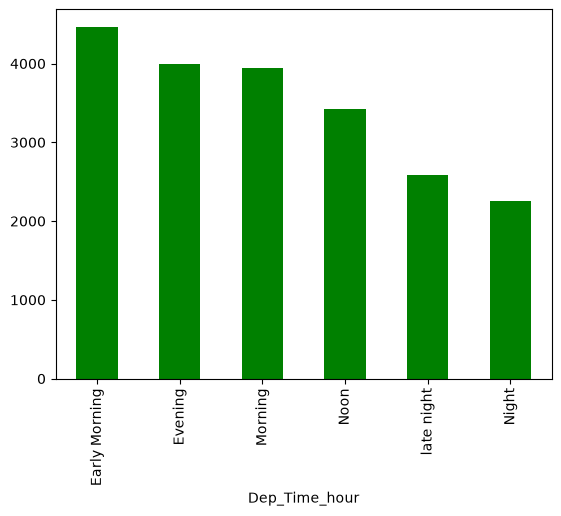

In [33]:
data['Dep_Time_hour'].apply(flight_dep_time).value_counts().plot(kind="bar" , color="g")

# 6.. Pre-process Duration Feature & extract meaningful features from it..
Lets Apply pre-processing on duration column,
-->> Once we pre-processed our Duration feature , lets extract Duration hours and minute from duration..

-->> As my ML model is not able to understand this duration as it contains string values , 
thats why we have to tell our ML Model that this is hour & this is minute for each of the row ..

In [34]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [35]:
data["Duration"].unique()

<StringArray>
[ '2h 50m',  '7h 25m',     '19h',  '5h 25m',  '4h 45m',  '2h 25m', '15h 30m',
  '21h 5m', '25h 30m',  '7h 50m',
 ...
 '28h 35m', '33h 40m', '36h 50m',  '31h 5m', '32h 35m', '39h 55m', '39h 35m',
 '30h 35m', '36h 40m', '35h 55m']
Length: 425, dtype: str

In [36]:
def preprocess_duration(x):
    if 'h' not in x:
        x = '0h' + ' ' + x
    elif 'm' not in x:
        x = x + ' ' +'0m'
        
    return x

In [37]:
data['Duration'] = data['Duration'].apply(preprocess_duration)

In [38]:
data['Duration']

0         2h 50m
1         7h 25m
2         19h 0m
3         5h 25m
4         4h 45m
          ...   
20677     9h 20m
20678    19h 20m
20679     3h 30m
20680    21h 15m
20681    14h 45m
Name: Duration, Length: 20682, dtype: str

In [39]:
data['Duration_hours'] = data['Duration'].apply(lambda x : int(x.split(' ')[0][0:-1]))

In [40]:
data['Duration_mins'] = data['Duration'].apply(lambda x : int(x.split(' ')[1][0:-1]))

In [41]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25


In [42]:
pd.to_timedelta(data["Duration"]).dt.components.hours

0         2
1         7
2        19
3         5
4         4
         ..
20677     9
20678    19
20679     3
20680    21
20681    14
Name: hours, Length: 20682, dtype: int64

In [43]:
data["Duration"]

0         2h 50m
1         7h 25m
2         19h 0m
3         5h 25m
4         4h 45m
          ...   
20677     9h 20m
20678    19h 20m
20679     3h 30m
20680    21h 15m
20681    14h 45m
Name: Duration, Length: 20682, dtype: str

In [44]:
data['Duration_total_mins'] = data['Duration'].str.replace('h' ,"*60").str.replace(' ' , '+').str.replace('m' , "*1").apply(eval)

In [45]:
data['Duration_total_mins']

0         170
1         445
2        1140
3         325
4         285
         ... 
20677     560
20678    1160
20679     210
20680    1275
20681     885
Name: Duration_total_mins, Length: 20682, dtype: int64

In [46]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_day',
       'Journey_month', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_mins', 'Duration_total_mins'],
      dtype='str')

<Axes: xlabel='Duration_total_mins', ylabel='Price'>

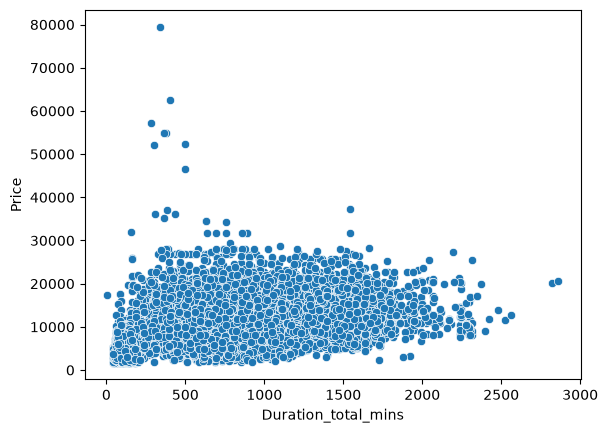

In [47]:
sns.scatterplot(x="Duration_total_mins" , y="Price" , data=data)

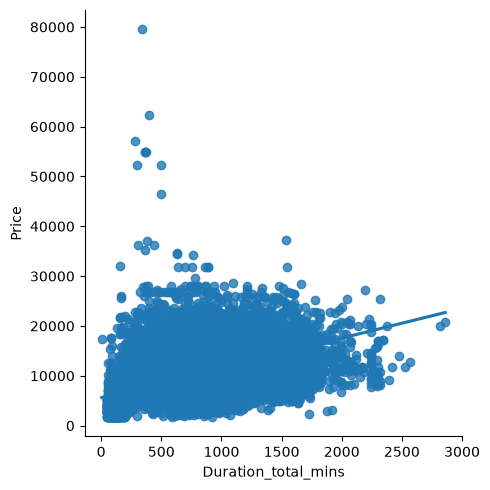

In [48]:
sns.lmplot(x="Duration_total_mins" , y="Price" , data=data)

### lets understand whether total stops affect price or not !

<Axes: xlabel='Duration_total_mins', ylabel='Price'>

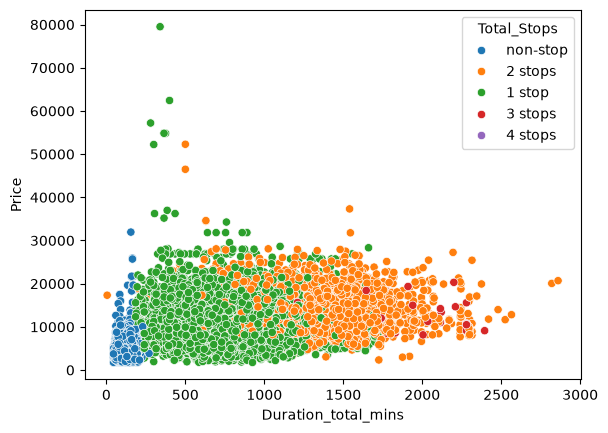

In [49]:
sns.scatterplot(x="Duration_total_mins" , y="Price" , hue="Total_Stops", data=data)

'''
Non stops flights take less duration while their fare is also low, then as the stop increases, 
duration also increases and price also increases(in most of the cases)

'''

## 8.. on which route Jet Airways is extremely used?

In [50]:
data['Airline']=='Jet Airways'

0        False
1        False
2         True
3        False
4        False
         ...  
20677     True
20678    False
20679    False
20680    False
20681     True
Name: Airline, Length: 20682, dtype: bool

In [51]:
data[data['Airline']=='Jet Airways'].groupby('Route').size().sort_values(ascending=False)

Route
CCU → BOM → BLR          1769
DEL → BOM → COK          1662
BLR → BOM → DEL           740
BLR → DEL                 725
CCU → DEL → BLR           620
DEL → JAI → BOM → COK     401
BOM → HYD                 399
DEL → AMD → BOM → COK     272
DEL → IDR → BOM → COK     159
DEL → NAG → BOM → COK     118
DEL → COK                  80
DEL → ATQ → BOM → COK      65
DEL → LKO → BOM → COK      58
DEL → BHO → BOM → COK      51
DEL → BDQ → BOM → COK      48
DEL → JDH → BOM → COK      38
DEL → MAA → BOM → COK      34
CCU → GAU → BLR            33
DEL → IXC → BOM → COK      20
BLR → MAA → DEL            19
BLR → BDQ → DEL            17
DEL → UDR → BOM → COK      17
BOM → DEL → HYD            10
CCU → BOM → PNQ → BLR       8
BOM → BDQ → DEL → HYD       5
DEL → DED → BOM → COK       5
BOM → JDH → DEL → HYD       3
BLR → BOM → JDH → DEL       3
DEL → CCU → BOM → COK       3
BOM → VNS → DEL → HYD       2
BOM → UDR → DEL → HYD       2
BOM → IDR → DEL → HYD       2
BOM → DED → DEL → HYD       1
dtyp

### b.. Performing Airline vs Price Analysis..
    ie find price distribution & 5-point summary of each Airline..

In [52]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_day',
       'Journey_month', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_mins', 'Duration_total_mins'],
      dtype='str')

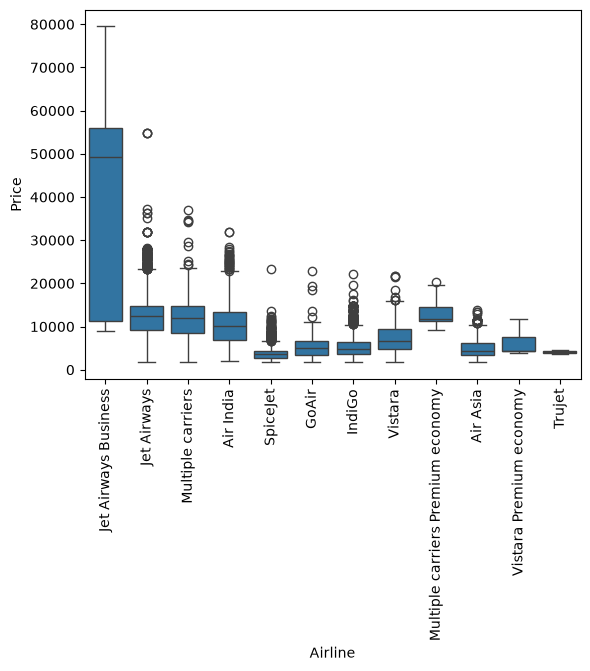

In [53]:
sns.boxplot(y='Price' , x='Airline' , data=data.sort_values('Price' , ascending=False))
plt.xticks(rotation="vertical")
plt.show()

'''

Conclusion--> From graph we can see that Jet Airways Business have the highest Price., 
              Apart from the first Airline almost all are having similar median

'''

## 9.. Applying one-hot Encoding on data..

In [54]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25,445


'''

Categorical data refers to a data type that can be stored into groups/categories/labels 
Examples of categorical variables are  age group, educational level,blood type etc.. 


Numerical data refers to the data that is in the form of numbers, 
Examples of numerical data are height, weight, age etc.. 

Numerical data has two categories: discrete data and continuous data


Discrete data : It basically takes countable numbers like 1, 2, 3, 4, 5, and so on. 
                In case of infinity, these numbers will keep going on...
                age of a fly : 8 , 9 day etc..
                
Continuous data : which is continuous in nature 
                  amount of sugar , 11.2 kg  , temp of a city  , your bank balance !
                  
For example, salary levels and performance classifications are discrete variables, 
whereas height and weight are continuous variables.

'''

In [55]:
cat_col = [col for col in data.columns if data[col].dtype=="object"]

In [56]:
num_col = [col for col in data.columns if data[col].dtype!="object"]

In [57]:
cat_col 

[]

In [58]:
num_col

['Airline',
 'Date_of_Journey',
 'Source',
 'Destination',
 'Route',
 'Duration',
 'Total_Stops',
 'Additional_Info',
 'Price',
 'Journey_day',
 'Journey_month',
 'Journey_year',
 'Dep_Time_hour',
 'Dep_Time_minute',
 'Arrival_Time_hour',
 'Arrival_Time_minute',
 'Duration_hours',
 'Duration_mins',
 'Duration_total_mins']

In [59]:
cat_col

[]

In [60]:
data['Source'].unique()

<StringArray>
['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Length: 5, dtype: str

In [61]:
for sub_category in data['Source'].unique():
    data['Source_'+sub_category] = data['Source'].apply(lambda x : 1 if x==sub_category else 0)

In [62]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


##  10.. Lets Perform target guided encoding on Data
ofcourse we can use One-hot , but if we have more sub-categories , it creates curse of dimensionality
lets use Target Guided Mean Encoding in such case to get rid of curse of dimensionality..

In [63]:
'''

Now on 2 features , Airline & Destination , we can apply on-hot as there is no such order
but total_stops is my ordinal data , it makes no sense if we apply on-hot on top of this..
similarly if we have any feature which have more categories , it is not good to apply one-hot as it will create 
curse of dimensionality issue , which leads to usage of more resources of your pc..

So we can think for appplying mean Encoding or better techniques like Target Guided Ordinal Encoding ! 


'''

'\n\nNow on 2 features , Airline & Destination , we can apply on-hot as there is no such order\nbut total_stops is my ordinal data , it makes no sense if we apply on-hot on top of this..\nsimilarly if we have any feature which have more categories , it is not good to apply one-hot as it will create \ncurse of dimensionality issue , which leads to usage of more resources of your pc..\n\nSo we can think for appplying mean Encoding or better techniques like Target Guided Ordinal Encoding ! \n\n\n'

In [64]:
cat_col

[]

In [65]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0


In [66]:
data["Airline"].nunique()

12

In [67]:
airlines = data.groupby(["Airline"])["Price"].mean().sort_values().index

In [68]:
airlines

Index(['SpiceJet', 'Trujet', 'Air Asia', 'IndiGo', 'GoAir',
       'Vistara Premium economy', 'Vistara', 'Air India', 'Multiple carriers',
       'Jet Airways', 'Multiple carriers Premium economy',
       'Jet Airways Business'],
      dtype='str', name='Airline')

In [69]:
dict_airlines = {key:index for index , key in enumerate(airlines , 0)}

In [70]:
dict_airlines

{'SpiceJet': 0,
 'Trujet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara Premium economy': 5,
 'Vistara': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Jet Airways': 9,
 'Multiple carriers Premium economy': 10,
 'Jet Airways Business': 11}

In [71]:
data["Airline"] = data["Airline"].map(dict_airlines)

In [72]:
data["Airline"]

0        3
1        7
2        9
3        3
4        3
        ..
20677    9
20678    8
20679    2
20680    7
20681    9
Name: Airline, Length: 20682, dtype: int64

In [73]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0


In [74]:
data["Destination"].unique()

<StringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [75]:
'''

till now , Delhi has only one Airport which is IGI & its second Airport is yet to build in Greater Noida (Jewar) 
which is neighbouring part of Delhi so we will consider New Delhi & Delhi as same

but in future , these conditions may change..


'''

'\n\ntill now , Delhi has only one Airport which is IGI & its second Airport is yet to build in Greater Noida (Jewar) \nwhich is neighbouring part of Delhi so we will consider New Delhi & Delhi as same\n\nbut in future , these conditions may change..\n\n\n'

In [76]:
data["Destination"].replace('New Delhi' , 'Delhi' , inplace=True)

0           Delhi
1        Banglore
2          Cochin
3        Banglore
4           Delhi
           ...   
20677    Banglore
20678      Cochin
20679    Banglore
20680    Banglore
20681      Cochin
Name: Destination, Length: 20682, dtype: str

In [77]:
data["Destination"].unique()

<StringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [78]:
dest = data.groupby(['Destination'])['Price'].mean().sort_values().index

In [79]:
dest

Index(['Kolkata', 'Delhi', 'Hyderabad', 'Banglore', 'New Delhi', 'Cochin'], dtype='str', name='Destination')

In [80]:
dict_dest = {key:index for index , key in enumerate(dest , 0)}

In [81]:
dict_dest

{'Kolkata': 0,
 'Delhi': 1,
 'Hyderabad': 2,
 'Banglore': 3,
 'New Delhi': 4,
 'Cochin': 5}

In [82]:
data['Destination'] = data['Destination'].map(dict_dest)

In [83]:
data['Destination']

0        4
1        3
2        5
3        3
4        4
        ..
20677    3
20678    5
20679    3
20680    3
20681    5
Name: Destination, Length: 20682, dtype: int64

In [84]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,4,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0


## 11.. Perform Label(Manual) Encoding on Data

In [85]:
data['Total_Stops']

0        non-stop
1         2 stops
2         2 stops
3          1 stop
4          1 stop
           ...   
20677      1 stop
20678      1 stop
20679    non-stop
20680     2 stops
20681      1 stop
Name: Total_Stops, Length: 20682, dtype: str

In [86]:
data['Total_Stops'].unique()

<StringArray>
['non-stop', '2 stops', '1 stop', '3 stops', '4 stops']
Length: 5, dtype: str

In [87]:
stop = {'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}

In [88]:
data['Total_Stops'] = data['Total_Stops'].map(stop)

In [89]:
data['Total_Stops']

0        0
1        2
2        2
3        1
4        1
        ..
20677    1
20678    1
20679    0
20680    2
20681    1
Name: Total_Stops, Length: 20682, dtype: int64

## b. Remove Un-necessary features

In [90]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,4,BLR → DEL,2h 50m,0,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0


In [91]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_day',
       'Journey_month', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_mins', 'Duration_total_mins', 'Source_Banglore',
       'Source_Kolkata', 'Source_Delhi', 'Source_Chennai', 'Source_Mumbai'],
      dtype='str')

In [92]:
data['Additional_Info'].value_counts()/len(data)*100

Additional_Info
No info                         78.169423
In-flight meal not included     18.426651
No check-in baggage included     3.128324
1 Long layover                   0.159559
Change airports                  0.053186
Business class                   0.033846
No Info                          0.014505
1 Short layover                  0.004835
Red-eye flight                   0.004835
2 Long layover                   0.004835
Name: count, dtype: float64

In [93]:
data['Journey_year'].unique()

array([2019], dtype=int32)

In [94]:
'''

lets drop Date_of_Journey as well as we have already extracted "Journey_hour" , "jpuney_month" , Journey_day"..
Additional_Info contains almost 80% no_info , so we can drop this column ..
lets drop Duration_total_mins as we have already extracted "Duration_hours" & "Duration_mins"
Lets drop "Source" feature as well as we have already perform feature encoding on this Feature 
lets drop Journey_year as well , as it has constant values throughtout dataframe which is 2019..

'''

'\n\nlets drop Date_of_Journey as well as we have already extracted "Journey_hour" , "jpuney_month" , Journey_day"..\nAdditional_Info contains almost 80% no_info , so we can drop this column ..\nlets drop Duration_total_mins as we have already extracted "Duration_hours" & "Duration_mins"\nLets drop "Source" feature as well as we have already perform feature encoding on this Feature \nlets drop Journey_year as well , as it has constant values throughtout dataframe which is 2019..\n\n'

In [96]:
data.drop(['Date_of_Journey' , 'Additional_Info' , 'Duration_total_mins' , 'Source' , 'Journey_year'] , axis=1 , inplace=True)

In [97]:
data.columns

Index(['Airline', 'Destination', 'Route', 'Duration', 'Total_Stops', 'Price',
       'Journey_day', 'Journey_month', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_mins', 'Source_Banglore', 'Source_Kolkata', 'Source_Delhi',
       'Source_Chennai', 'Source_Mumbai'],
      dtype='str')

In [98]:
data.head(5)

,Airline,Destination,Route,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,4,BLR → DEL,2h 50m,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,CCU → IXR → BBI → BLR,7h 25m,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0
2,9,5,DEL → LKO → BOM → COK,19h 0m,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0
3,3,3,CCU → NAG → BLR,5h 25m,1,6218,12,5,18,5,23,30,5,25,0,1,0,0,0
4,3,4,BLR → NAG → DEL,4h 45m,1,13302,1,3,16,50,21,35,4,45,1,0,0,0,0


In [103]:
data.drop(['Route'] , axis=1 , inplace=True)

## we can drop Route as well bcz Route is directly related to Total stops & considering 2 same features doesnt make sense while building ML model..

In [104]:
data.head(3)

,Airline,Destination,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,4,2h 50m,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,7h 25m,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0
2,9,5,19h 0m,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0


In [105]:
data.drop(['Duration'] , axis=1 , inplace=True)

## we can drop "Duration" feature as we have extracted "Duration hour" & "Duration Minute"..

In [106]:
data.head(2)

,Airline,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,4,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0


## 12. Let's perform Outlier detection

Here the list of data visualization plots to spot the outliers.
1. Box and whisker plot (box plot).
2. Scatter plot.
3. Histogram.
4. Distribution Plot.

In [107]:
def plot(df, col):
    fig , (ax1 , ax2 , ax3) = plt.subplots(3,1)
    
    sns.distplot(df[col] , ax=ax1)
    sns.boxplot(df[col] , ax=ax2)
    sns.distplot(df[col] , ax=ax3 , kde=False)

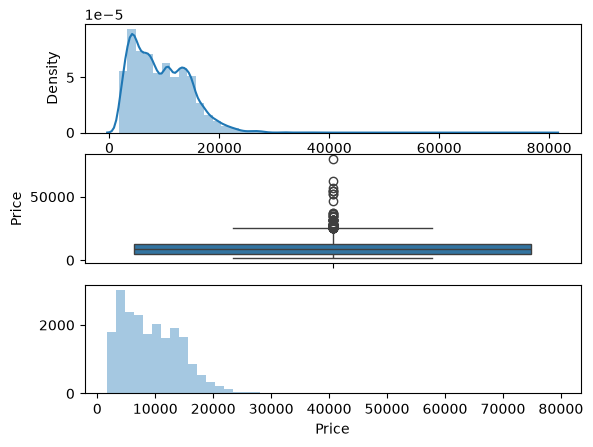

In [108]:
plot(data , 'Price')

 If Features Are Skewed We Use the below Technique which is IQR
    Data which are greater than IQR +1.5 IQR and data which are below than IQR - 1.5 IQR are my outliers
    where ,  IQR = 75th%ile data - 25th%ile data

     & IQR +- 1.5 IQR  will be changed depending upon the domain ie it could be sometimes IQR +- 3IQR 

In [109]:
q1 = data['Price'].quantile(0.25)
q3 = data['Price'].quantile(0.75)

iqr = q3- q1

maximum = q3 + 1.5*iqr
minimum = q1 - 1.5*iqr

In [110]:
print(maximum)

25125.0


In [111]:
print(minimum)

-7091.0


In [112]:
print([price for price in data['Price'] if price> maximum or price<minimum])

[27430, 36983, 26890, 26890, 25139, 27210, 52229, 26743, 26890, 25735, 27992, 26890, 26890, 26890, 25735, 54826, 31783, 27992, 26890, 26890, 25430, 36235, 27210, 26890, 25735, 54826, 26890, 35185, 79512, 28097, 27992, 26890, 25735, 26092, 31825, 25913, 25735, 27992, 31825, 62427, 54826, 31825, 25430, 26890, 36235, 26890, 25735, 28322, 25735, 25735, 31825, 26890, 27992, 34273, 46490, 29528, 26890, 26890, 26890, 34503, 26890, 27992, 26890, 26890, 26890, 27992, 25735, 34608, 25703, 26890, 31825, 27282, 25735, 27992, 52285, 31945, 26890, 27992, 57209, 26890, 31825, 26480, 27405, 26182, 27726, 27939, 26046, 26126, 26101, 27519, 25450, 26447, 25916, 37316, 26042, 25325, 27670, 26235, 27933, 27245, 27810, 25990, 25592, 26168, 25293, 28073, 26296, 28639, 26587, 28066, 25844, 25238, 26486]


In [113]:
len([price for price in data['Price'] if price> maximum or price<minimum])

113

## b. How to deal with outlier

In [114]:
### wherever I have price >35K just replace replace it with median of Price

data['Price'] = np.where(data['Price']>=35000 , data['Price'].median() , data['Price'])

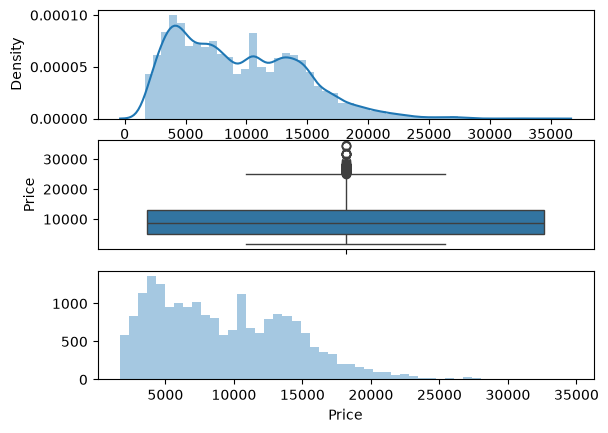

In [115]:
plot(data , 'Price')

## 13.. Lets Perform feature selection

'''
    : Feature Selection
    Finding out the best feature which will contribute and have good relation with target variable. 
    
    
    Q-> Why to apply Feature Selection?
    To select important features ie to get rid of curse of dimensionality ie..or to get rid of duplicate features
    
'''

In [116]:
X = data.drop(['Price'] , axis=1)

In [117]:
y = data['Price']

In [118]:
from sklearn.feature_selection import mutual_info_regression

In [119]:
imp = mutual_info_regression(X , y)

In [120]:
'''
Estimate mutual information for a continuous target variable.

Mutual information between two random variables is a non-negative
value, which measures the dependency between the variables. 
If It is equal to zero it means two random variables are independent, and higher
values mean higher dependency.

'''

'\nEstimate mutual information for a continuous target variable.\n\nMutual information between two random variables is a non-negative\nvalue, which measures the dependency between the variables. \nIf It is equal to zero it means two random variables are independent, and higher\nvalues mean higher dependency.\n\n'

In [121]:
imp

array([0.82687265, 0.63834454, 0.56774432, 0.18324631, 0.29600252,
       0.4723799 , 0.53142437, 0.57367899, 0.60641408, 0.73553548,
       0.32152533, 0.20390439, 0.21076793, 0.28537969, 0.0807609 ,
       0.09720474])

In [122]:
imp_df = pd.DataFrame(imp , index=X.columns)

In [123]:
imp_df.columns = ['importance']

In [124]:
imp_df

,importance
Airline,0.826873
Destination,0.638345
Total_Stops,0.567744
Journey_day,0.183246
Journey_month,0.296003
Dep_Time_hour,0.472380
Dep_Time_minute,0.531424
Arrival_Time_hour,0.573679
Arrival_Time_minute,0.606414
Duration_hours,0.735535


In [125]:
imp_df.sort_values(by='importance' , ascending=False)

,importance
Airline,0.826873
Duration_hours,0.735535
Destination,0.638345
Arrival_Time_minute,0.606414
Arrival_Time_hour,0.573679
Total_Stops,0.567744
Dep_Time_minute,0.531424
Dep_Time_hour,0.472380
Duration_mins,0.321525
Journey_month,0.296003


## 14.. Lets Build ML model

In [126]:
from sklearn.model_selection import train_test_split

In [127]:
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.25, random_state=42)

what we often do in modelling:
a..Initially ,lets build basic random model.
b..then later-on , we will try to improve this model using some parameters..
c..Then we will try to improve it..
d..Then we will hyper-tune my model to get optimal value of parameters in order to achieve optimal value of params..

In [128]:
from sklearn.ensemble import RandomForestRegressor

In [129]:
ml_model = RandomForestRegressor()

In [130]:
ml_model.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [131]:
y_pred = ml_model.predict(X_test)

In [132]:
y_pred

array([12820.105, 19629.96 ,  6464.07 , ...,  4986.23 , 12084.735,
       10420.16 ], shape=(5171,))

In [133]:
from sklearn import metrics

In [134]:
metrics.r2_score(y_test , y_pred)

0.6901258831146214